# Scenario A2: Single Supplier — With REC (Net Generators)

**Description:** Single supplier mandate with a Renewable Energy Community.
All 9 participants (3 prosumers + 6 consumers) are members of REC_01.
Internal energy sharing is performed proportionally before external supplier
billing. Prosumers are modelled as **net generators** (RES only, no local load).

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Net generator** (RES only, no local load) |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Settlement basis | Corrected meter readings after REC sharing |
| Battery | None |

**Research role:** Tests the value of a single community-wide REC under a
single-supplier mandate, where generators contribute purely as RES sources.

**Comparison pairs (net-generator track):**
- A2 vs A1 → incremental value of adding a REC (single supplier)
- A2 vs B2 → single vs multi-supplier with equivalent REC structure
- A2 vs B2-forecasts → effect of explicit forecast scheduling on REC performance

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "A2_single_supplier_with_rec(net generators).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="A2 Single Supplier With REC (Net Generators)")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: A2 Single Supplier With REC (Net Generators)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: A2 Single Supplier With REC (Net Generators)
  System  : Single Supplier Mandate with REC - Scenario A2
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (35136, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (12, 27)
✓ Profit/los

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – A2 SINGLE SUPPLIER WITH REC (NET GENERATORS)

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      283.12
      Balancing Rewards   : €       71.15
      Retail Sales        : €   21,123.93
      ────────────────────────────────────────────
      Total Revenue       : €   21,478.19

    COSTS:
      Market Purchases    : €    3,463.56
      Balancing Penalties  : €       70.57
      Retail Purchases     : €    1,107.46
      ────────────────────────────────────────────
      Total Costs          : €    4,641.59

    PROFIT/LOSS:
      Annual Total         : €   16,836.60
      Monthly Average      : €    1,403.05

    IMBALANCE:
      System Position      : SHORT
      Total Imbalance      :         0.01 MWh
      BG Actual Position   :        91.65 MWh
      BG Forecast Position :        91.65 MWh

    REC SHARING:
      Shared Energy        :        86.47 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

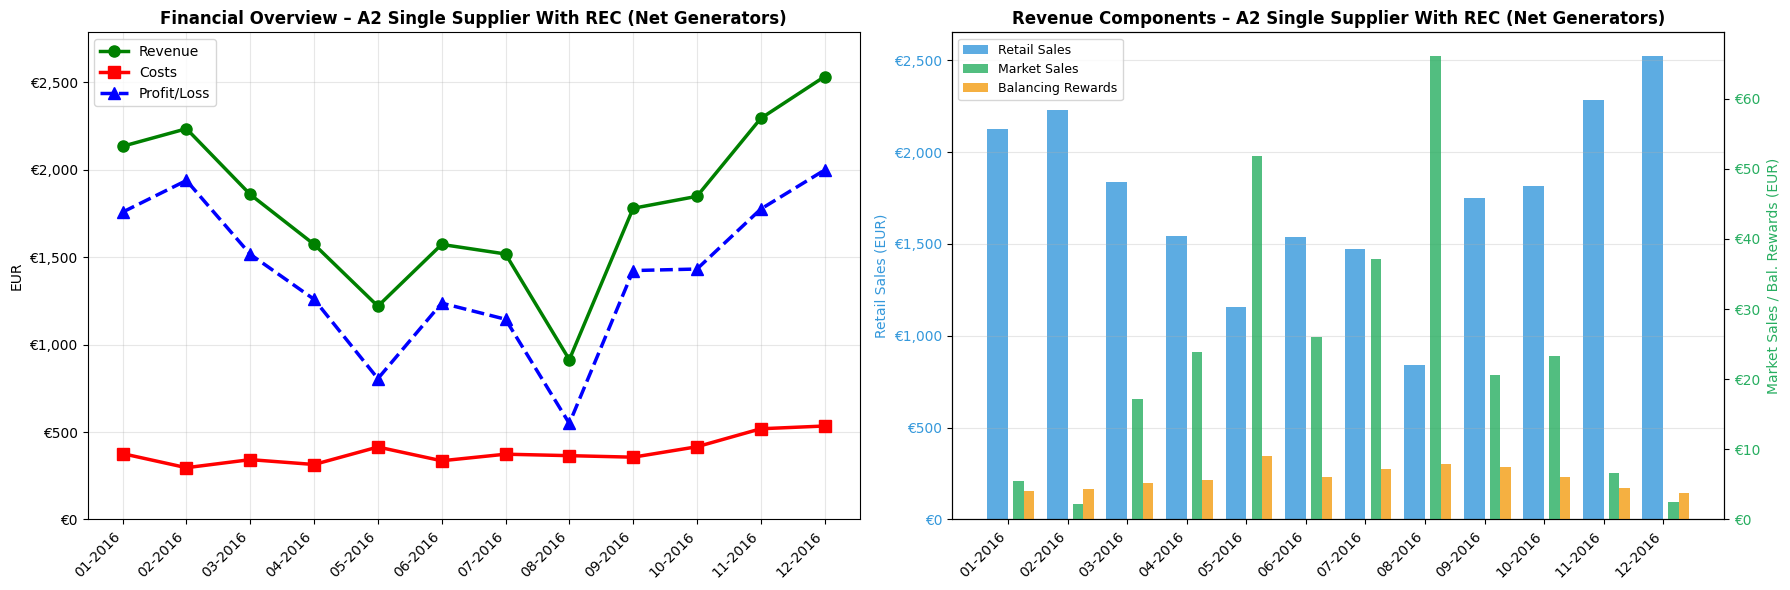

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

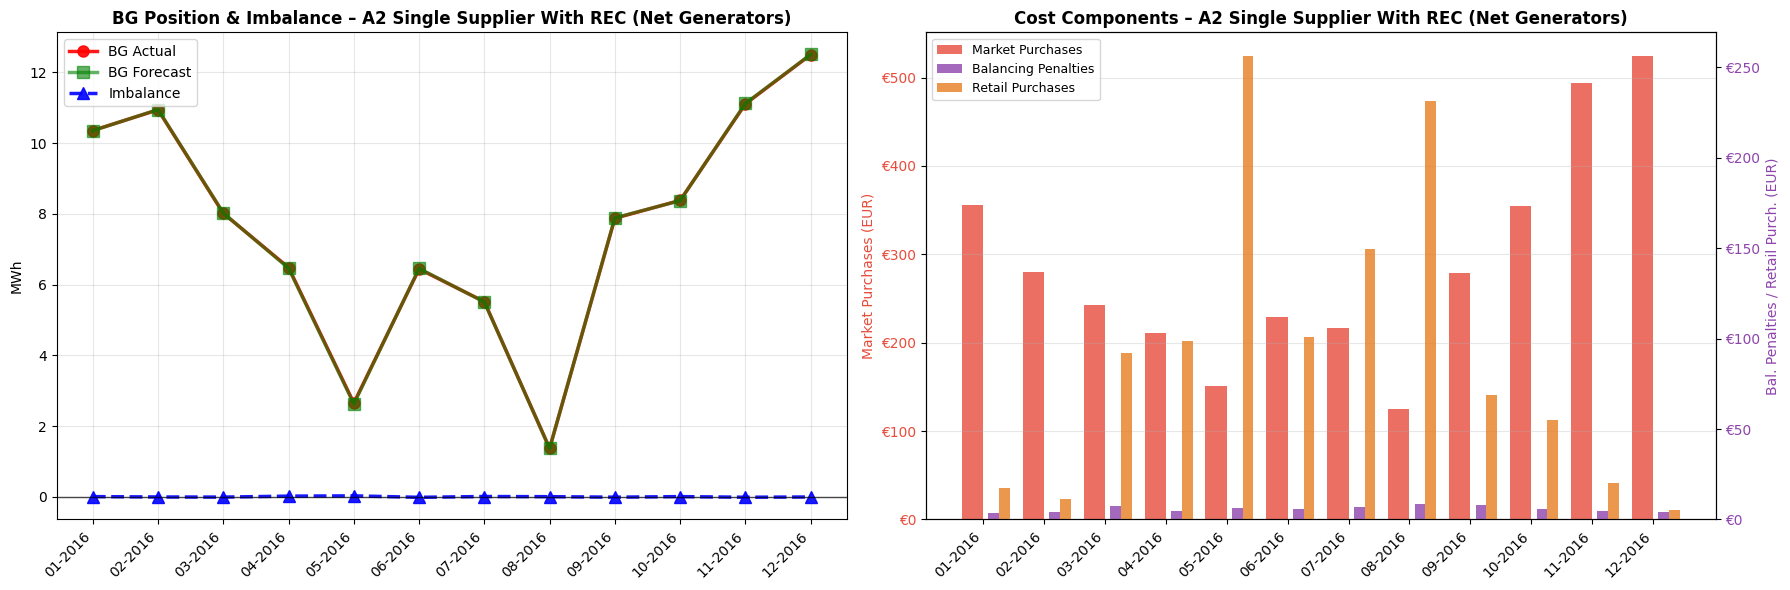

In [6]:
pipe.plot_imbalances()

## 7. REC Analysis & Monthly Data
Display total energy shared within the REC and monthly analysis DataFrame with all financial metrics.

In [7]:
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")
pipe.es_monthly_analysis_df

Total Shared Energy: 86.47 MWh


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,11.740290,0.180791,395.381203,4.664840,-1.175045,0.030932,29.579375,...,2.830740,5.529485,4.009907,2124.610587,2134.149978,355.532769,3.465164,17.445818,376.443751,1757.706227
1,02-2016,SUP_A,BG_A,12.437626,0.121162,314.480153,1.882415,-1.345223,0.021096,22.463459,...,5.166612,2.230811,4.371368,2227.909681,2234.511860,280.228549,4.270064,11.479986,295.978598,1938.533261
2,03-2016,SUP_A,BG_A,10.352735,1.026866,274.725242,15.168111,-1.208871,0.091983,24.094009,...,8.053855,17.181040,5.183383,1835.981919,1858.346342,242.508724,7.437098,92.125373,342.071195,1516.275147
3,04-2016,SUP_A,BG_A,8.797402,1.032603,241.398511,19.683030,-1.127719,0.173916,25.257687,...,10.424519,23.901538,5.622824,1543.789923,1573.314285,210.669928,4.842401,98.756626,314.268956,1259.045329
4,05-2016,SUP_A,BG_A,6.573481,2.838498,173.232440,44.972758,-0.817546,0.292393,22.993579,...,10.051994,51.825879,9.036340,1158.746094,1219.608314,151.316925,6.396274,256.569430,414.282629,805.325685
5,06-2016,SUP_A,BG_A,8.714424,1.064149,260.907549,21.989673,-1.039799,0.152722,27.651608,...,8.873123,25.999581,6.102997,1540.705861,1572.808439,229.172007,5.689004,100.718614,335.579625,1237.228814
6,07-2016,SUP_A,BG_A,8.391116,1.604744,247.727572,31.466332,-1.056170,0.221446,27.138380,...,10.686351,37.108990,7.205016,1473.856573,1518.170580,216.402585,7.160590,149.652266,373.215442,1144.955138
7,08-2016,SUP_A,BG_A,4.780504,2.522270,142.692441,58.390462,-0.596044,0.295230,27.268374,...,9.241013,66.161635,7.847995,839.869441,913.879070,124.678803,8.750842,231.413630,364.843275,549.035796
8,09-2016,SUP_A,BG_A,9.887178,0.704498,316.982297,17.102633,-1.173166,0.121973,30.137590,...,8.898765,20.628851,7.436418,1751.414876,1779.480145,279.304556,7.860264,68.948406,356.113226,1423.366919
9,10-2016,SUP_A,BG_A,10.156405,0.581479,398.922563,19.880555,-1.103117,0.095788,36.908256,...,5.754070,23.348741,6.078231,1818.460150,1847.887122,354.876465,6.015983,54.890263,415.782711,1432.104411


In [8]:
import pandas as pd
import numpy as np

df = pipe.es_timeseries_df.copy()
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

# === BALANCING GROUP ===
for sid in df['supplier_id'].unique():
    sdf = df[df['supplier_id'] == sid]
    bg_actual = sdf['balancing_group_actual_mwh'].sum()
    bg_forecast = sdf['balancing_group_forecast_mwh'].sum()
    imbalance = sdf['imbalance_mwh'].sum()
    reward = sdf['imbalance_reward'].sum()
    penalty = sdf['imbalance_penalty'].sum()
    pos = "LONG (Surplus)" if imbalance < 0 else "SHORT (Deficit)"
    print(f"=== {sid} ===")
    print(f"Actual BG net position: {bg_actual:.4f} MWh")
    print(f"Forecast BG net position (ID): {bg_forecast:.4f} MWh")
    print(f"Net imbalance volume: {imbalance:+.4f} MWh")
    print(f"System position: {pos}")
    print(f"Balancing reward (annual): €{reward:.2f}")
    print(f"Imbalance penalty (annual): €{penalty:.2f}")
    print(f"Net balancing settlement: {reward - penalty:+.2f} €")
    print()

# === REVENUE & COSTS ===
for sid in df['supplier_id'].unique():
    sdf = df[df['supplier_id'] == sid]
    mkt_sales = sdf['da_sale_commitment_eur'].sum() + sdf['id_sale_adjustment_eur'].sum()
    bal_rewards = sdf['imbalance_reward'].sum()
    retail_sales = sdf['sales_revenue_eur'].sum()
    total_rev = mkt_sales + bal_rewards + retail_sales
    
    mkt_purchases = sdf['da_purchase_commitment_eur'].sum() + sdf['id_purchase_adjustment_eur'].sum()
    bal_penalties = sdf['imbalance_penalty'].sum()
    retail_purchases = sdf['purchase_costs_eur'].sum()
    total_costs = mkt_purchases + bal_penalties + retail_purchases
    profit = total_rev - total_costs
    
    print(f"=== {sid} REVENUE ===")
    print(f"Market Sales: €{mkt_sales:.2f} ({mkt_sales/total_rev*100:.2f}%)")
    print(f"Balancing Rewards: €{bal_rewards:.2f} ({bal_rewards/total_rev*100:.2f}%)")
    print(f"Retail Sales: €{retail_sales:.2f} ({retail_sales/total_rev*100:.2f}%)")
    print(f"TOTAL REVENUE: €{total_rev:.2f}")
    print()
    print(f"=== {sid} COSTS ===")
    print(f"Market Purchases: €{mkt_purchases:.2f} ({mkt_purchases/total_costs*100:.2f}%)")
    print(f"Balancing Penalties: €{bal_penalties:.2f} ({bal_penalties/total_costs*100:.2f}%)")
    print(f"Retail Purchases (feed-in): €{retail_purchases:.2f} ({retail_purchases/total_costs*100:.2f}%)")
    print(f"TOTAL COSTS: €{total_costs:.2f}")
    print()
    print(f"=== {sid} PROFIT ===")
    print(f"Annual Profit: €{profit:.2f}")
    monthly = sdf.groupby('month').agg({
        'sales_revenue_eur': 'sum', 'da_sale_commitment_eur': 'sum', 'id_sale_adjustment_eur': 'sum',
        'imbalance_reward': 'sum', 'da_purchase_commitment_eur': 'sum', 'id_purchase_adjustment_eur': 'sum',
        'imbalance_penalty': 'sum', 'purchase_costs_eur': 'sum',
    })
    monthly['total_rev'] = monthly['sales_revenue_eur'] + monthly['da_sale_commitment_eur'] + monthly['id_sale_adjustment_eur'] + monthly['imbalance_reward']
    monthly['total_cost'] = monthly['da_purchase_commitment_eur'] + monthly['id_purchase_adjustment_eur'] + monthly['imbalance_penalty'] + monthly['purchase_costs_eur']
    monthly['profit'] = monthly['total_rev'] - monthly['total_cost']
    print(f"Monthly avg: €{monthly['profit'].mean():.2f}")
    print(f"Monthly min: €{monthly['profit'].min():.2f}")
    print(f"Monthly max: €{monthly['profit'].max():.2f}")

=== SUP_A ===
Actual BG net position: 91.6541 MWh
Forecast BG net position (ID): 91.6467 MWh
Net imbalance volume: +0.0075 MWh
System position: SHORT (Deficit)
Balancing reward (annual): €71.15
Imbalance penalty (annual): €70.57
Net balancing settlement: +0.58 €

=== SUP_A REVENUE ===
Market Sales: €283.12 (1.32%)
Balancing Rewards: €71.15 (0.33%)
Retail Sales: €21123.93 (98.35%)
TOTAL REVENUE: €21478.19

=== SUP_A COSTS ===
Market Purchases: €3463.56 (74.62%)
Balancing Penalties: €70.57 (1.52%)
Retail Purchases (feed-in): €1107.46 (23.86%)
TOTAL COSTS: €4641.59

=== SUP_A PROFIT ===
Annual Profit: €16836.60
Monthly avg: €1403.05
Monthly min: €549.04
Monthly max: €1998.12


In [9]:
# === MONTHLY BG POSITIONS ===
sdf = df[df['supplier_id'] == 'SUP_A']
monthly_bg = sdf.groupby('month').agg({
    'balancing_group_actual_mwh': 'sum',
    'balancing_group_forecast_mwh': 'sum',
    'imbalance_mwh': 'sum',
})
for m in range(1, 13):
    r = monthly_bg.loc[m]
    print(f"{m:02d}: A={r['balancing_group_actual_mwh']:.4f}, F={r['balancing_group_forecast_mwh']:.4f}, I={r['imbalance_mwh']:+.6f}")

01: A=10.3585, F=10.3535, I=+0.004959
02: A=10.9448, F=10.9501, I=-0.005337
03: A=8.0162, F=8.0250, I=-0.008803
04: A=6.4820, F=6.4632, I=+0.018880
05: A=2.6512, F=2.6250, I=+0.026155
06: A=6.4429, F=6.4578, I=-0.014864
07: A=5.5165, F=5.5088, I=+0.007695
08: A=1.3700, F=1.3670, I=+0.003077
09: A=7.8768, F=7.8875, I=-0.010787
10: A=8.3809, F=8.3760, I=+0.004900
11: A=11.1114, F=11.1241, I=-0.012644
12: A=12.5029, F=12.5087, I=-0.005754


In [10]:
sdf = df[df['supplier_id'] == 'SUP_A']
monthly = sdf.groupby('month').agg({
    'da_purchase_commitment_eur': 'sum', 'id_purchase_adjustment_eur': 'sum',
    'imbalance_penalty': 'sum', 'purchase_costs_eur': 'sum',
    'da_sale_commitment_eur': 'sum', 'id_sale_adjustment_eur': 'sum',
    'imbalance_reward': 'sum', 'sales_revenue_eur': 'sum',
})
monthly['mp'] = monthly['da_purchase_commitment_eur'] + monthly['id_purchase_adjustment_eur']
monthly['ms'] = monthly['da_sale_commitment_eur'] + monthly['id_sale_adjustment_eur']
print("Monthly Costs: MP | BP | RP | Total")
for m in range(1, 13):
    r = monthly.loc[m]
    t = r['mp'] + r['imbalance_penalty'] + r['purchase_costs_eur']
    print(f"  {m:02d}: {r['mp']:.2f} | {r['imbalance_penalty']:.2f} | {r['purchase_costs_eur']:.2f} | {t:.2f}")
print()
print("Monthly Revenue: MS | BR | RS | Total")
for m in range(1, 13):
    r = monthly.loc[m]
    t = r['ms'] + r['imbalance_reward'] + r['sales_revenue_eur']
    print(f"  {m:02d}: {r['ms']:.2f} | {r['imbalance_reward']:.2f} | {r['sales_revenue_eur']:.2f} | {t:.2f}")

Monthly Costs: MP | BP | RP | Total
  01: 355.53 | 3.47 | 17.45 | 376.44
  02: 280.23 | 4.27 | 11.48 | 295.98
  03: 242.51 | 7.44 | 92.13 | 342.07
  04: 210.67 | 4.84 | 98.76 | 314.27
  05: 151.32 | 6.40 | 256.57 | 414.28
  06: 229.17 | 5.69 | 100.72 | 335.58
  07: 216.40 | 7.16 | 149.65 | 373.22
  08: 124.68 | 8.75 | 231.41 | 364.84
  09: 279.30 | 7.86 | 68.95 | 356.11
  10: 354.88 | 6.02 | 54.89 | 415.78
  11: 493.85 | 4.74 | 20.05 | 518.64
  12: 525.02 | 3.95 | 5.41 | 534.37

Monthly Revenue: MS | BR | RS | Total
  01: 5.53 | 4.01 | 2124.61 | 2134.15
  02: 2.23 | 4.37 | 2227.91 | 2234.51
  03: 17.18 | 5.18 | 1835.98 | 1858.35
  04: 23.90 | 5.62 | 1543.79 | 1573.31
  05: 51.83 | 9.04 | 1158.75 | 1219.61
  06: 26.00 | 6.10 | 1540.71 | 1572.81
  07: 37.11 | 7.21 | 1473.86 | 1518.17
  08: 66.16 | 7.85 | 839.87 | 913.88
  09: 20.63 | 7.44 | 1751.41 | 1779.48
  10: 23.35 | 6.08 | 1818.46 | 1847.89
  11: 6.69 | 4.55 | 2282.31 | 2293.55
  12: 2.51 | 3.71 | 2526.27 | 2532.49


In [11]:
# === REC SHARED ENERGY ===
rec_shared = df.groupby('month')['internal_shared_energy_mwh'].sum()
print("Monthly REC Shared Energy:")
for m in range(1, 13):
    print(f"  {m:02d}: {rec_shared.loc[m]:.4f} MWh")
print(f"\nTotal: {rec_shared.sum():.4f} MWh")

total_load = pipe.es_data['load_actual'].sum().sum()
total_gen = pipe.es_data['res_actual'].sum().sum()
total_shared = rec_shared.sum()
print(f"Community load: {total_load:.4f} MWh")
print(f"Community gen: {total_gen:.4f} MWh")
print(f"Shared/load: {total_shared/total_load*100:.2f}%")
print(f"Shared/gen: {total_shared/total_gen*100:.2f}%")

if hasattr(pipe, 'corrected_load_df') and not pipe.corrected_load_df.empty:
    orig_load = pipe.es_data['load_actual'].sum().sum()
    corr_load = pipe.corrected_load_df.sum().sum()
    orig_gen = pipe.es_data['res_actual'].sum().sum()
    corr_gen = pipe.corrected_gen_df.sum().sum()
    print(f"\nLoad reduction from REC: {orig_load - corr_load:.4f} MWh")
    print(f"Gen reduction from REC: {orig_gen - corr_gen:.4f} MWh")

Monthly REC Shared Energy:
  01: 2.8307 MWh
  02: 5.1666 MWh
  03: 8.0539 MWh
  04: 10.4245 MWh
  05: 10.0520 MWh
  06: 8.8731 MWh
  07: 10.6864 MWh
  08: 9.2410 MWh
  09: 8.8988 MWh
  10: 5.7541 MWh
  11: 4.0638 MWh
  12: 2.4265 MWh

Total: 86.4714 MWh
Community load: 1873.8208 MWh
Community gen: 660.9249 MWh
Shared/load: 4.61%
Shared/gen: 13.08%

Load reduction from REC: 43.2357 MWh
Gen reduction from REC: 43.2357 MWh
